# LRD IR spectrum: T_dust

## Preparation

In [ ]:
import numpy as np
from scipy import integrate, optimize
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const

import sys,os
from pathlib import Path

# 设置路径为 project 的路径。按需调整
project_path = Path('~/Codes/JWST_LRD_SED/LRD_IR_spectrum').expanduser()
os.chdir(project_path)

# 添加 src 目录到 sys.path
module_path = project_path / 'src'
sys.path.insert(0, str(module_path))
from LRD_IR_spectrum import *


u.set_enabled_equivalencies(u.spectral())  # enable convenient equivalencies for converting between nu, lambda

In [2]:
Orion_opacity = OpacityData('data/opacity_law/Orion.opc')
Temple_SED = IncidentSED('data/raw/quasar5.template')
# Temple_SED = IncidentSED('data/raw/quasar5_ly.template')

/Users/chenkejian/Codes/JWST_LRD_SED/LRD_IR_spectrum/src/LRD_IR_spectrum/utils.py:52: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [9]:
from scipy import special
def test_T_0(beta):
    c = const.c.cgs.value
    h = const.h.cgs.value
    k_B = const.k_B.cgs.value
    q_ir = 1.4e-24
    L = 1e46
    r = 1 * u.pc.to(u.cm)
    
    return ( (L/r**2) / (q_ir * 2*h/c**2 * ((4*np.pi)**2) * special.gamma(4+beta) * special.zeta(4+beta)) ) ** (1/(4+beta)) * h/k_B
    # return ( L/(r**2) * c**2/h / (32 * np.pi**2) * (h/k_B)**(4+beta) / (special.gamma(4+beta) * special.zeta(4+beta)) / q_ir ) ** (1/(4+beta))

test_T_0(1.6)

1587.099470049977

## Compare with ZL

In [19]:
%load_ext line_profiler
import others_code.Barvainis_T_profile as ZL_script

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [ ]:
%lprun -f ZL_script.OrionLRD -T profile_ZL ZL_script.OrionLRD(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, )

/Users/chenkejian/miniconda3/envs/main/lib/python3.12/site-packages/line_profiler/ipython_extension.py:97: UserWarning: Could not extract a code object for the object <class 'others_code.Barvainis_T_profile.OrionLRD'>
  profile = LineProfiler(*funcs)
/Users/chenkejian/Library/Mobile Documents/com~apple~CloudDocs/北大/科研/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  x = h * nu / (k_B * T)
/Users/chenkejian/Library/Mobile Documents/com~apple~CloudDocs/北大/科研/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:23: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)
/Users/chenkejian/Library/Mobile Documents/com~apple~CloudDocs/北大/科研/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/utils.py:40: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), kind='linear')



*** Profile printout saved to text file 'profile_ZL'. 


Timer unit: 1e-09 s

In [ ]:
%lprun -m LRD_IR_spectrum model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)

/Users/chenkejian/Library/Mobile Documents/com~apple~CloudDocs/北大/科研/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:23: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)


Timer unit: 1e-09 s

Total time: 0 s
File: /Users/chenkejian/Library/Mobile Documents/com~apple~CloudDocs/北大/科研/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/Barvainis_1987.py
Function: _calc_r_in at line 25

Line #      Hits         Time  Per Hit   % Time  Line Contents
    25                                               def _calc_r_in(self):  # in [pc]
    26                                                   return self.r_in_B87(self.L_UV, self.T_sub)

Total time: 0 s
File: /Users/chenkejian/Library/Mobile Documents/com~apple~CloudDocs/北大/科研/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/Barvainis_1987.py
Function: tau_UV_profile at line 28

Line #      Hits         Time  Per Hit   % Time  Line Contents
    28                                               def tau_UV_profile(self, r):
    29                                                   """Optical depth profile"""
    30                                                   return self.sigma_H_UV_ext * self.NH_profile(r) 

Total time: 0 s
File:

In [ ]:
ZL_model = ZL_script.OrionLRD(n_0=40, gamma=.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
r_array = np.geomspace(ZL_model.r_in, ZL_model.r_out, 1000)
UV_Flux_arr_ZL = [ZL_model.UV_Flux(r) for r in r_array]

model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model.r_in = ZL_model.r_in
plt.loglog(r_array, 1e18 * model.UV_Flux(r_array), )
plt.loglog(r_array, np.array(_12))

[2822.956452100784,
 2767.465888892712,
 2713.0649096174807,
 2659.73213622703,
 2607.4466098915545,
 2556.1877827818635,
 2505.935510012785,
 2456.6700417444526,
 2408.372015438394,
 2361.0224482653657,
 2314.6027296619823,
 2269.0946140332203,
 2224.480213597924,
 2180.7419913745284,
 2137.862754304249,
 2095.8256465090326,
 2054.6141426816444,
 2014.2120416052942,
 1974.6034598002595,
 1935.7728252950326,
 1897.70487151953,
 1860.3846313179945,
 1823.797431079223,
 1787.9288849818436,
 1752.7648893523694,
 1718.2916171338265,
 1684.4955124627902,
 1651.3632853527085,
 1618.881906481415,
 1587.0386020808141,
 1555.8208489267136,
 1525.216369426852,
 1495.2131268052028,
 1465.7993203806573,
 1436.963380938238,
 1408.6939661910471,
 1380.979956331142,
 1353.8104496676199,
 1327.1747583501979,
 1301.0624041766011,
 1275.4631144821328,
 1250.366818109799,
 1225.7636414594338,
 1201.6439046142448,
 1177.9981175432933,
 1154.8169763783976,
 1132.0913597640135,
 1109.8123252786622,
 1087.97

/Users/chenkejian/Library/Mobile Documents/com~apple~CloudDocs/北大/科研/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:22: RuntimeWarning: divide by zero encountered in divide
  x = h * nu / (k_B * T)


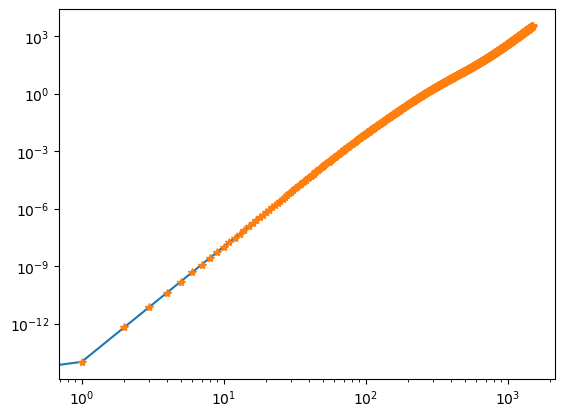

In [ ]:
ZL_model = ZL_script.OrionLRD(n_0=40, gamma=.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
T_array = np.linspace(0, 1500, 1500+1)
IR_Flux_arr_ZL = np.array([ZL_model.IR_Flux(T) for T in T_array])

model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model.r_in = ZL_model.r_in

plt.loglog(T_array, 1e18 * model.IR_Flux(T_array), )
plt.loglog(T_array, np.array(IR_Flux_arr_ZL), '*')

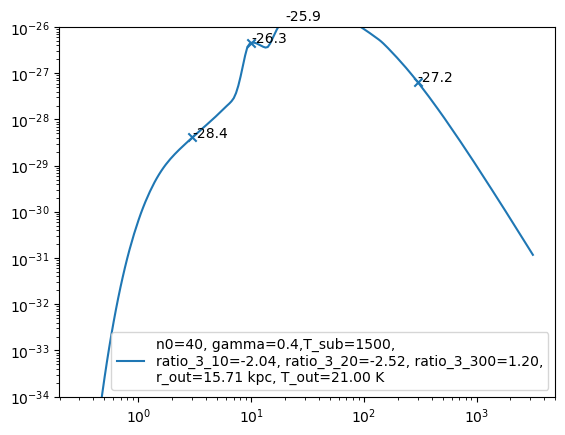

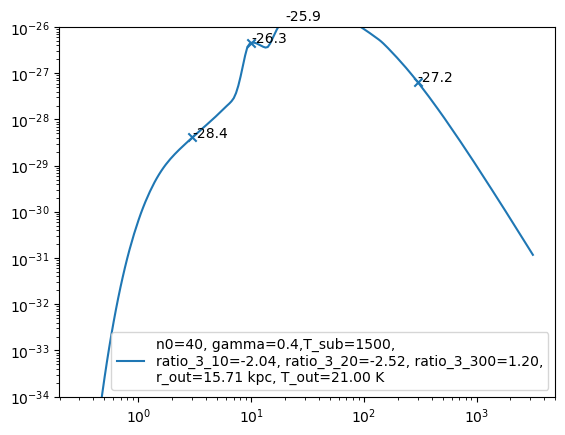

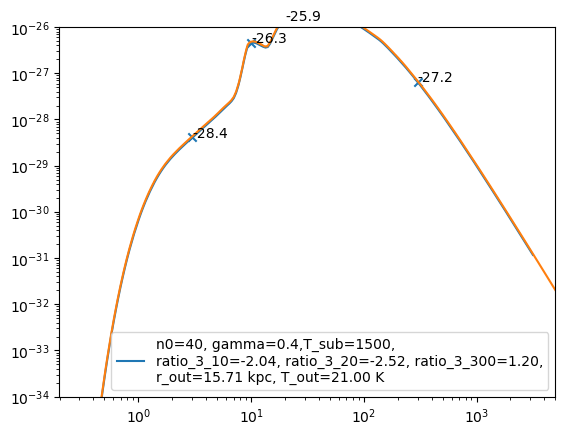

In [ ]:
import Barvainis
# import importlib
# importlib.reload(Barvainis)

fig, ax = Barvainis.plot_model(gamma=0.4, n0=40)
ax.autoscale(enable=False)
model = B87Model(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22) 
L_nu = model.calc_L_nu(opacity=Orion_opacity)
ax.loglog(Orion_opacity.wavelength, 1.5e-4*L_nu, '-', label=r'$L_\nu$')
fig

## Input Data

### Opacity

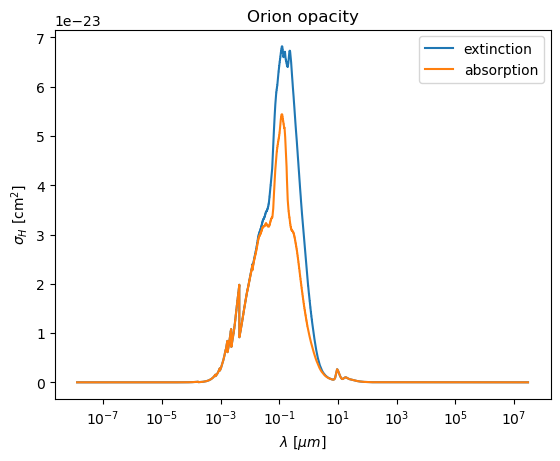

In [20]:
plt.loglog(Orion_opacity.wavelength.to(u.micron), Orion_opacity.sigma_H_ext.to(u.cm**2), label='extinction')
plt.loglog(Orion_opacity.wavelength.to(u.micron), Orion_opacity.sigma_H_abs.to(u.cm**2), label='absorption')
plt.yscale('linear')
plt.xlabel(rf"$\lambda \ [\mu m] $")
plt.ylabel(rf"$\sigma_H \ [{{\rm cm}}^2]$")
plt.title(rf"Orion opacity")
plt.legend()

$$
    \int L_\nu {\rm d}\nu = \int \nu L_\nu {\rm d}\log\nu
$$

/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:24: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)
/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:24: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)


/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_647/1987095199.py:13: RuntimeWarning: divide by zero encountered in divide
  return (const.h * const.c / const.k_B).to(u.K * u.micron).value / x


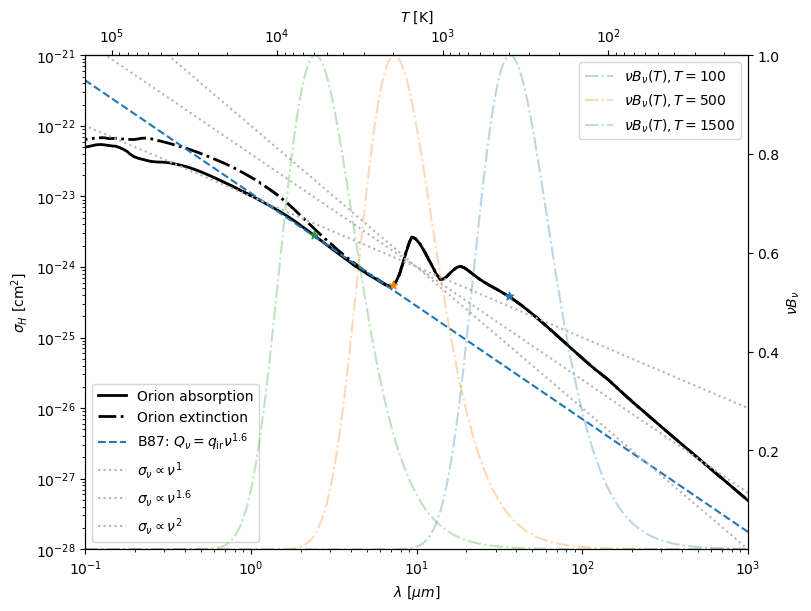

In [21]:
from LRD_IR_spectrum.model_base import Planck_B_nu


wavelength_array = Orion_opacity.wavelength.to(u.micron)

fig, ax = plt.subplots(layout='constrained', figsize=(8, 6))

# 绘制图形
ax.plot(wavelength_array, Orion_opacity.sigma_H_abs, '-', label='Orion absorption', linewidth=2, c='k', zorder=0)
ax.plot(wavelength_array, Orion_opacity.sigma_H_ext, '-.', label='Orion extinction', linewidth=2, c='k', zorder=0)

def wavelength_to_temperature(x):
    return (const.h * const.c / const.k_B).to(u.K * u.micron).value / x

T_axis = ax.secondary_xaxis('top', functions=(wavelength_to_temperature, wavelength_to_temperature))

# B87 所使用的 Q 的 power-law
q_ir = 1.4e-24
beta = 1.6
ax.plot(wavelength_array, q_ir * Orion_opacity.nu_cgs**beta * Orion_opacity.sigma_H_abs.max().value, '--', label=rf'B87: $Q_\nu = q_{{\rm ir}} \nu^{{{beta}}}$')

# 参考的 power-law 直线
for beta in [1, 1.6, 2]:
    ax.plot(wavelength_array, 1e-24 * (wavelength_array / 1e1)**(-beta), ':', color='0.7', label=rf'$\sigma_\nu \propto \nu^{{{beta}}}$')
    
# for T in [100, 1500]:
#     nu = (const.k_B * 4*T * u.K).to(u.Hz, u.spectral())
#     ax.scatter(nu.to(u.micron, u.spectral()), Orion_opacity(nu), marker='*', label=rf'$4T, T = {T}$')

# 设置坐标轴的缩放
ax.set_xscale('log')
ax.set_yscale('log')

# 设置坐标轴的范围
ax.set_xlim(1e-1, 1e3)
ax.set_ylim(1e-28, 1e-21)

# 添加图例
ax.legend(loc='lower left')
ax.set_xlabel(r"$\lambda$ [$\mu m$]")
ax.set_xlabel(r"$\lambda$ [$\mu m$]")
T_axis.set_xlabel(r"$T$ [K]")
ax.set_ylabel(r"$\sigma_H \ [{\rm cm^2}]$")

# 单开一个 twinx 轴，绘制 nu * B_nu
ax2 = ax.twinx()
for T in [100, 500, 1500]:
    nu_B_nu: np.ndarray = Orion_opacity.nu.cgs * Planck_B_nu(Orion_opacity.nu_cgs, T)
    ax2.semilogx(wavelength_array, nu_B_nu / nu_B_nu.max(), 
               '-.', alpha=.3, label=rf'$\nu B_\nu(T), T = {T}$')
    # 绘制峰值对应的 sigma_H 的点
    nu = (const.k_B * 4*T * u.K).to(u.Hz)
    ax.scatter(nu.to(u.micron), Orion_opacity.interp_abs(nu), marker='*', ) #label=rf'$4T, T = {T}$')
    
    
ax2.set_ylim(ax2.dataLim.ymax / 1e6, ax2.dataLim.ymax * 1e0)
ax2.set_ylabel(r"$\nu B_\nu$")
ax2.legend(loc='best')

### Temple SED

In [22]:
TempleWavelength_5_AA, TempleLlambda_5 = np.loadtxt('data/quasar5_ly.template',comments='#',delimiter=' ',usecols=(0,1),unpack=True)
TempleFrequency_5 = 3e10/(TempleWavelength_5_AA*1e-8) # Hz
TempleLnu5 = TempleLlambda_5*TempleWavelength_5_AA**2/3e18
L_bol = 2.4e46 # erg/s
NormalizedFactorAt1450 = L_bol/4.4/2.0675e+15 # erg/s/Hz
Temple_NormalizedLnu_5 = TempleLnu5/TempleLnu5[np.argmin(np.abs(TempleWavelength_5_AA-1450))]*NormalizedFactorAt1450
print(-1*np.trapz(Temple_NormalizedLnu_5,3e10/(TempleWavelength_5_AA*1e-8)))

1.0180418510839197e+46


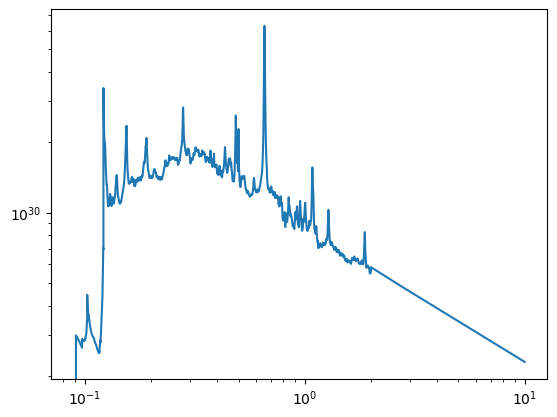

In [23]:
plt.loglog(Temple_SED.wavelength.to(u.micron), Temple_SED.L_nu)

## Model Tests (Speed, convergence, ...)

### Speed

In [24]:
# model = B87Model(n_0=40, gamma=0.2, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
# model = OrionLRDModel(n_0=40, gamma=0.2, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity)
model = OrionLRDModel(n_0=40, gamma=0.2, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
# model.method_L_nu = 'quad'
# %time res_1 = model.calc_L_nu(Orion_opacity)
# model.method_L_nu = 'quad_log'
# %time res_2 = model.calc_L_nu(Orion_opacity)
model.method_L_nu = 'trapz'
%time res_3=model.calc_L_nu(r_sample_num=1000)
model.method_L_nu = 'trapz_log'
%time res_4=model.calc_L_nu(r_sample_num=1000)

/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/utils.py:52: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


CPU times: user 232 ms, sys: 228 ms, total: 460 ms
Wall time: 502 ms
CPU times: user 215 ms, sys: 188 ms, total: 403 ms
Wall time: 409 ms


In [ ]:
%timeit model.calc_L_nu(r_sample_num=100)

162 ms ± 5.22 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit model.calc_L_nu(r_sample_num=100)

153 ms ± 3.53 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%load_ext line_profiler

%time %lprun -s -m LRD_IR_spectrum -m scipy.interpolate._interpolate model.calc_L_nu(r_sample_num=1000)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


/Users/chenkejian/miniconda3/envs/main/lib/python3.12/site-packages/line_profiler/line_profiler.py:212: UserWarning: Adding a function with a __wrapped__ attribute. You may want to profile the wrapped function by adding comb.__wrapped__ instead.
  self.add_function(item)
/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:23: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)
/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/utils.py:40: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


CPU times: user 301 ms, sys: 230 ms, total: 531 ms
Wall time: 656 ms


Timer unit: 1e-09 s

Total time: 0.124276 s
File: /Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/OrionLRD.py
Function: IR_Flux at line 49

Line #      Hits         Time  Per Hit   % Time  Line Contents
    49                                               def IR_Flux(self, T, method:str = 'trapz_log'):
    50                                                   """计算方程右端，即 IR Flux。
    51                                                   T 可以是标量，或者 numpy 数组。返回值始终为 array
    52                                                   """
    53         1      43000.0  43000.0      0.0          nu_cgs = self.opacity.nu_cgs
    54                                           
    55         1       1000.0   1000.0      0.0          def integrand(nu, T):
    56                                                       return self.opacity.interp_abs(nu * u.Hz).cgs.value * Planck_B_nu(nu, T)
    57                                           
    58         1          0.0      0.0      0.0    

In [ ]:
import glob

%snakeviz -t  glob.glob('*.txt')

 
*** Profile stats marshalled to file '/var/folders/my/27ldnx8910x52m595stkm5y00000gn/T/tmpntkd6fry'.
Opening SnakeViz in a new tab...
snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2Fvar%2Ffolders%2Fmy%2F27ldnx8910x52m595stkm5y00000gn%2FT%2Ftmpntkd6fry


404 GET /static/images/sort_asc_disabled.png (127.0.0.1) 14.35ms
404 GET /static/images/sort_desc_disabled.png (127.0.0.1) 12.20ms


In [ ]:
%prun model.calc_L_nu(r_sample_num=1000)

/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:23: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)
/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/utils.py:40: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


         3505 function calls (3430 primitive calls) in 0.566 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        3    0.158    0.053    0.167    0.056 _quadrature.py:22(trapezoid)
      5/1    0.151    0.030    0.000    0.000 {method 'control' of 'select.kqueue' objects}
        2    0.066    0.033    0.066    0.033 model_base.py:16(Planck_B_nu)
        1    0.058    0.058    0.195    0.195 OrionLRD.py:119(UV_Flux)
        3    0.052    0.017    0.220    0.073 utils.py:72(trapz_log)
        1    0.023    0.023    0.268    0.268 model_base.py:176(func)
        1    0.020    0.020    0.039    0.039 OrionLRD.py:55(integrand)
        1    0.016    0.016    0.017    0.017 OrionLRD.py:115(tau_nu_profile)
       15    0.009    0.001    0.009    0.001 {method 'reduce' of 'numpy.ufunc' objects}
        1    0.004    0.004    0.199    0.199 OrionLRD.py:90(T_dust_profile)
        1    0.001    0.001    0.088    0.088 OrionLRD.py:4

### Convergence

(0.1, 1000.0)

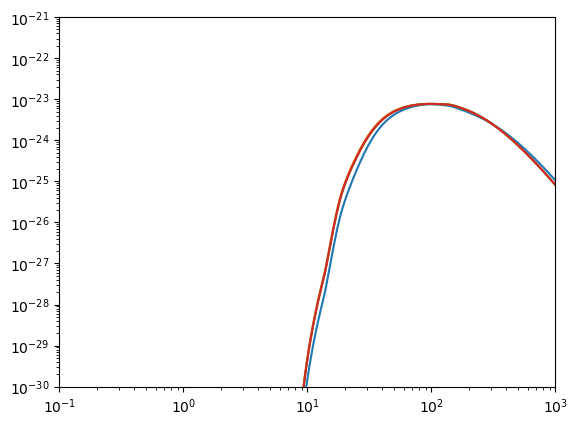

In [25]:
model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model.method_L_nu = 'trapz_log'
# model.method_L_nu = 'trapz'
for num in [10, 100, 1000, 10000]:
    plt.loglog(Orion_opacity.wavelength, model.calc_L_nu(r_sample_num=num))
plt.ylim(1e-30, 1e-21)
plt.xlim(1e-1, 1e3)

(0.1, 1000.0)

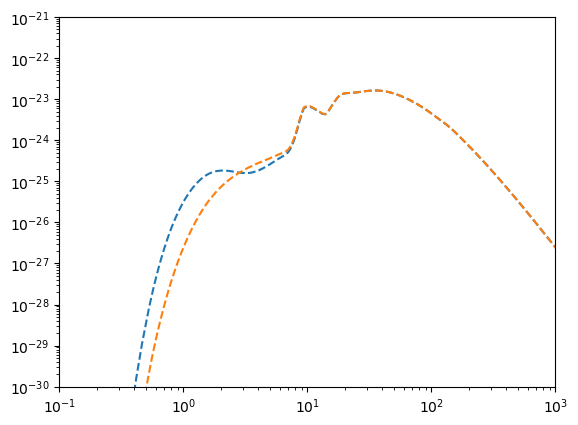

In [ ]:
# plt.loglog(Orion_opacity.wavelength, res_1, label='quad')
# plt.loglog(Orion_opacity.wavelength, res_2, '--', label='quad_log')
plt.loglog(Orion_opacity.wavelength, res_3, '--', label='trapz')
plt.loglog(Orion_opacity.wavelength, res_4, '--', label='trapz_log')
plt.ylim(1e-30, 1e-21)
plt.xlim(1e-1, 1e3)

## Model Results

In [28]:
model = OrionLRDModel(n_0=40, gamma=.4, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model.T_out

11.638040286246097

In [29]:
model.calc_L_nu([1,] * u.micron)

array([5.8202299e-126])

In [30]:
L_nu = model.calc_L_nu()
model.tau_ph = 0
L_nu_no_feedback = model.calc_L_nu()

In [31]:
(L_nu_no_feedback - L_nu).max()

1.7531260014778046e-24

In [ ]:

utils.trapz_log(Temple_SED.L_nu * Orion_opacity.interp_abs(Temple_SED.nu).cgs.value, Temple_SED.nu.cgs.value) / utils.trapz_log(Temple_SED.L_nu, Temple_SED.nu.cgs.value)

3.591518859053108e-23

In [ ]:

utils.trapz_log(Temple_SED.L_nu * Orion_opacity.interp_ext(Temple_SED.nu).cgs.value, Temple_SED.nu.cgs.value) / utils.trapz_log(Temple_SED.L_nu, Temple_SED.nu.cgs.value)

5.650332737909186e-23

In [ ]:
Orion_opacity.sigma_H_ext.max()

<Quantity 6.82e-23 cm2>

### Try: Z dependence

In [ ]:
factor = 10
Orion_opacity_10 = OpacityData('data/Orion_Tdust20_Sigma_23_Thickness_16_Hden_07.opc', factor)

model = OrionLRDModel(n_0=40, gamma=.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model_10 = OrionLRDModel(n_0=40 / factor, gamma=.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22 / factor, opacity=Orion_opacity_10, incident_SED=Temple_SED)

In [ ]:
(model.r_in, model_10.r_out), \
(model.r_in, model_10.r_out)

((0.8763944654691626, 20398.961065805583),
 (0.8763944654691626, 20398.961065805583))

In [ ]:
model.tau_nu_profile(Orion_opacity.nu, model.r_out).max(), \
model_10.tau_nu_profile(Orion_opacity_10.nu, model_10.r_out).max()

(5.1149999999999824, 5.115000000000006)

In [ ]:
model.tau_nu_profile(.55 * u.micron, model.r_out), \
model_10.tau_nu_profile(.55 * u.micron, model_10.r_out)

(2.77677599536942, 2.776775995369413)

In [ ]:
model.tau_nu_profile(Orion_opacity.nu[100], model.r_out), \
model_10.tau_nu_profile(Orion_opacity.nu[100], model_10.r_out)

(7.049999999999998e-14, 7.05000000000003e-14)

In [ ]:
model.NH_profile(model.r_out) / model_10.NH_profile(model_10.r_out)

10.0

In [ ]:
(model.IR_Flux(model.T_sub), model.UV_Flux(model.r_in) ),  \
(model_10.IR_Flux(model_10.T_sub), model_10.UV_Flux(model_10.r_in) ) 

((3.436203887877177e-15, 3.4362038878771783e-15),
 (3.436203887877177e-14, 3.436203887877179e-14))

In [ ]:
model.UV_Flux(model.r_in) - model.IR_Flux(model.T_sub), \
model_10.UV_Flux(model_10.r_in) - model_10.IR_Flux(model_10.T_sub)

/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:23: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)


(1.1832913578315177e-30, 1.8932661725304283e-29)

In [ ]:
L_nu_1 = model.calc_L_nu()
L_nu_10 = model_10.calc_L_nu()
np.nanmax((L_nu_1 - L_nu_10) / L_nu_1)

/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/utils.py:40: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/var/folders/my/27ldnx8910x52m595stkm5y00000gn/T/ipykernel_71028/3691732929.py:3: RuntimeWarning: invalid value encountered in divide
  np.nanmax((L_nu_1 - L_nu_10) / L_nu_1)


5.506683079489894e-14

### UV & IR Flux

In [ ]:
model = OrionLRDModel(n_0=40, gamma=.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)

In [ ]:
model.calc_L_nu()

/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:23: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)
/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/utils.py:40: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), kind='linear')


array([1.05853232e-43, 1.07227560e-43, 1.08838747e-43, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

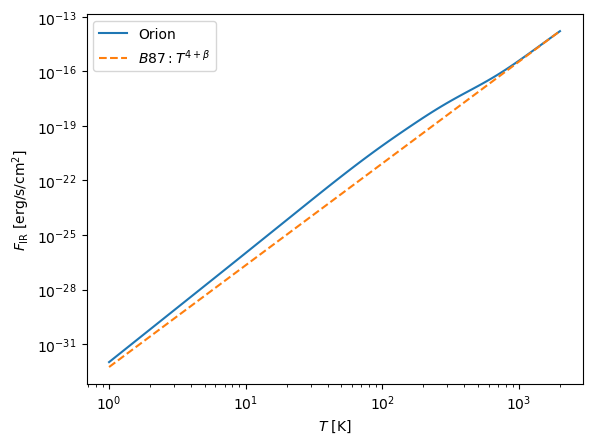

In [32]:
n_0 = 1
gamma = .5
T_array = np.geomspace(1, 2e3, 100)

model_LRD = OrionLRDModel(n_0=n_0, gamma=gamma, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model_B87 = B87Model(n_0=n_0, gamma=gamma, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity)
plt.loglog(T_array, model_LRD.IR_Flux(T_array), label=r'Orion')
plt.loglog(T_array, model_B87.IR_Flux(T_array), '--', label=r'$B87: T^{4+\beta}$')
plt.xlabel(r"$T$ [K]")
plt.ylabel(r"$F_{\rm IR}\ [{\rm erg/s/cm^2}]$")
plt.legend()

### T_dust(r) profile

gamma=1.5 cannot find r_out
gamma=2 cannot find r_out


Text(0.5, 1.0, '$n_0 = 100.0$')

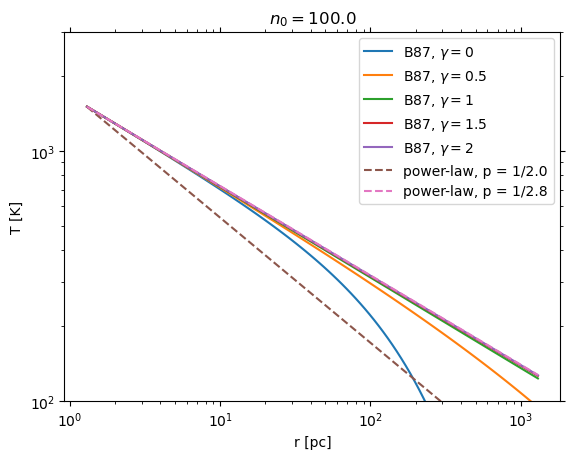

In [34]:
for gamma in [0, 0.5, 1, 1.5, 2]:
    model = B87Model(n_0=1e2, gamma=gamma, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=None)
    r_array = np.geomspace(model.r_in, 1e3*model.r_in, 100)
    
    plt.loglog(r_array, model.T_dust_profile(r_array), label=rf"B87, $\gamma={model.gamma}$")
    try:
        r_out = model.r_out
        if r_out < r_array[-1]:
            plt.scatter(r_out, model.T_dust_profile(r_out), marker='*')
    except R_out_Error:
        print(f"gamma={model.gamma} cannot find r_out")
        
for p in [1/2, 1/2.8]:
    plt.loglog(r_array, model.T_dust_power_law(p, r_array), '--', label=f"power-law, p = 1/{1/p}")
    
plt.ylim(bottom=1e2, top=model.T_sub * 2)
plt.legend()
plt.xlabel("r [pc]")
plt.ylabel("T [K]")
plt.tick_params(which='both', bottom=True, top=True, left=True, right=True)
plt.title(rf"$n_0 = {model.n_0}$")

In [ ]:
model = OrionLRDModel(n_0=40, gamma=.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model.tau_nu_profile(1e10 * u.Hz, 3)

/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:24: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)


1.073854060801634e-10

In [ ]:
import ipywidgets as widgets
from IPython.display import display


# 定义绘图函数
def plot_T_profile(model: LRD_IR_ModelBase, r_array, ax: plt.Axes | None = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.get_figure()
    ax: plt.Axes

    ax.loglog(r_array, model.T_dust_profile(r_array), label=rf"$n_0={model.n_0},\gamma={model.gamma}$")
    try:
        r_out = model.r_out
        if r_out < r_array[-1]:
            ax.scatter(r_out, model.T_dust_profile(r_out), marker='*', label=rf'$r_{{\rm out}} = {r_out:.2f}$')
    except R_out_Error:
        print(f"gamma={model.gamma} cannot find r_out")

    for p in [1/2, 1/2.8]:
        plt.loglog(r_array, model.T_dust_power_law(p, r_array), '--', label=f"power-law, p = 1/{1/p}")

    # ax.set_ylim(bottom=1e2, top=model.T_sub * 2) #TEMP
    ax.legend()
    ax.set_xlabel("r [pc]")
    ax.set_ylabel("T [K]")
    ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
    return fig, ax


# 创建交互式控件
def plot_T_profile_interactive(n_0, gamma):
    model = B87Model(n_0=n_0, gamma=gamma, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity)
    # model = SemiOrionLRDModel(n_0=n_0, gamma=gamma, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity)
    # model = OrionLRDModel(n_0=n_0, gamma=gamma, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
    r_array = np.geomspace(model.r_in, 2e4*model.r_in, 1000)
    fig, ax = plot_T_profile(model, r_array)

widgets.interactive(plot_T_profile_interactive,
                     n_0=widgets.FloatLogSlider(min=1, max=5, step=0.1, value=3, base=10), 
                     gamma=widgets.FloatSlider(min=0, max=2, step=0.01, value=1)
                     )

interactive(children=(FloatLogSlider(value=10.0, description='n_0', max=5.0, min=1.0), FloatSlider(value=1.0, …

### Spectrum
$$
         L_{\nu} = 4\pi \int_{r_{\rm in}}^{r_{\rm out}} \kappa_{\nu, \rm abs} B_{\nu}(T_{\rm d})\rho {\rm d}V \\
         = 4\pi \int_{r_{\rm in}}^{r_{\rm out}} \sigma_{\nu, \rm abs} B_{\nu}(T_{\rm d}) n(r) 4\pi r^2 {\rm d}r
$$

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'OrionLRDModel($n_0=$4.00e+01, $\\gamma=$0.4, \n    $L_{\\rm UV}=$1.00e+46, $T_{\\rm sub}=$1500, \n    $r_{\\rm in}=$8.76e-01, $r_{\\rm out}=$2.04e+04, $T_{\\rm out}=$14.8)\n    '}, xlabel='$\\lambda$ [$\\mu m$]', ylabel='$L_\\nu \\ [{\\rm erg/s}]$'>)

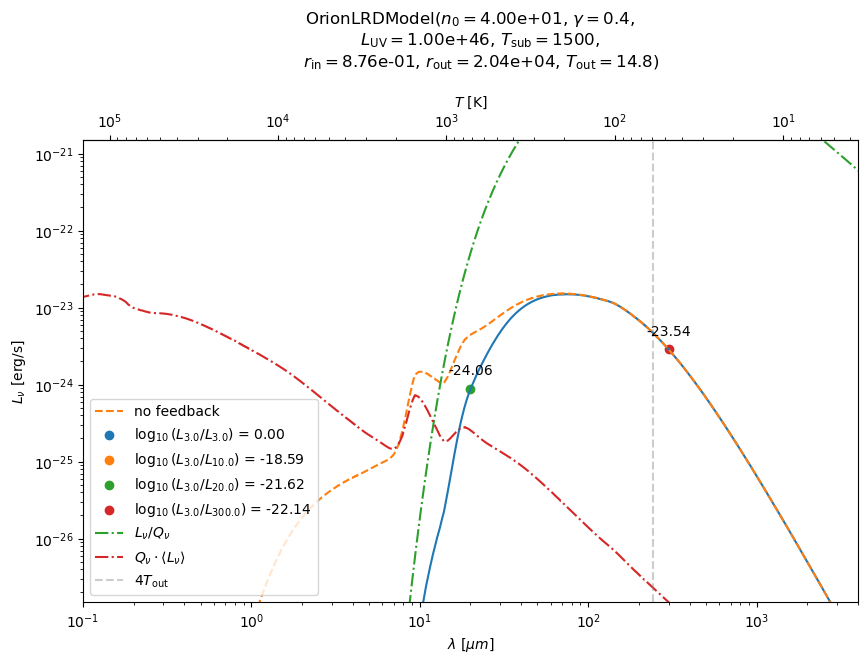

In [ ]:
def L_nu_contrast(L_nu_func, lambda_1, lambda_2):
    return np.log10( L_nu_func(lambda_1) / L_nu_func(lambda_2) )

def plot_L_nu(model: LRD_IR_ModelBase):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax: plt.Axes
    L_nu = model.calc_L_nu(r_sample_num=1000)
    L_nu_func = LogLogInterpolator(Orion_opacity.nu, L_nu) # 虽然 x 轴用的是 nu, 但由于启用了 u.spectral() 的等价关系，所以也可以用波长。
    ax.loglog(Orion_opacity.wavelength, L_nu, )
    model.tau_ph = 0
    L_nu_no_feedback = model.calc_L_nu(r_sample_num=1000)
    ax.loglog(Orion_opacity.wavelength, L_nu_no_feedback, '--', label='no feedback')
    
    
    # 对几个波段进行标注，计算对比度
    wavelength_points = [3, 10, 20, 300] * u.micron
    for wavelength in wavelength_points:
        y = L_nu_func(wavelength)
        lambda_1 = wavelength_points[0]
        lambda_2 = wavelength
        contrast = L_nu_contrast(L_nu_func, lambda_1, lambda_2)
        ax.scatter(wavelength, y, label = rf"$\log_{{10}}( L_{{{lambda_1.value}}}/L_{{{lambda_2.value}}} )$ = {contrast:.2f}")
        ax.annotate(f"{np.log10(y):.2f}", (wavelength.value, y), textcoords="offset points", xytext=(0, 10), ha='center')
        
        
    # 辅助线：sigma_H 和 multi-color BB
    sigma_H = Orion_opacity.sigma_H_abs.cgs.value
    ax.loglog(Orion_opacity.wavelength, L_nu / (sigma_H / sigma_H.max()), '-.', label=r'$L_\nu / Q_\nu$')
    ax.loglog(Orion_opacity.wavelength, (sigma_H / sigma_H.max()) * L_nu.max() , '-.', label=r'$Q_\nu \cdot \langle L_\nu \rangle$')
    
    # 设定坐标轴的范围
    ax.set_xlim(1e-1, 4e3)
    ax.set_ylim(L_nu.max() / 1e4, L_nu.max() * 1e2)
    
    # 坐标轴 label
    ax.set_xlabel(r"$\lambda$ [$\mu m$]")
    ax.set_ylabel(r"$L_\nu \ [{\rm erg/s}]$")
    
    # 上方的 T 轴
    def wavelength_to_temperature(x):
        return (const.h * const.c / const.k_B).to(u.K * u.micron).value / x

    T_axis = ax.secondary_xaxis('top', functions=(wavelength_to_temperature, wavelength_to_temperature))
    T_axis.set_xlabel(r"$T$ [K]")
    ax.axvline(wavelength_to_temperature(4 * model.T_out), color='grey', alpha=.4, linestyle='--', label = r"$4 T_{\rm out}$")
    
    # 添加图例
    ax.legend()
    ax.set_title(rf"{model:latex}")
    
    return fig, ax

# model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
plot_L_nu(model)

interactive(children=(FloatLogSlider(value=1000.0, description='n_0', max=6.0), FloatSlider(value=0.0, descrip…

<function __main__.interactive_plot(n_0, gamma)>

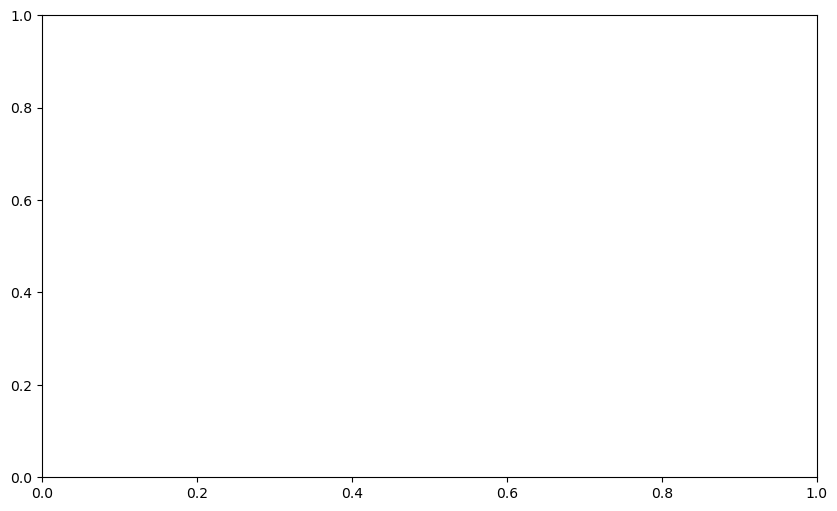

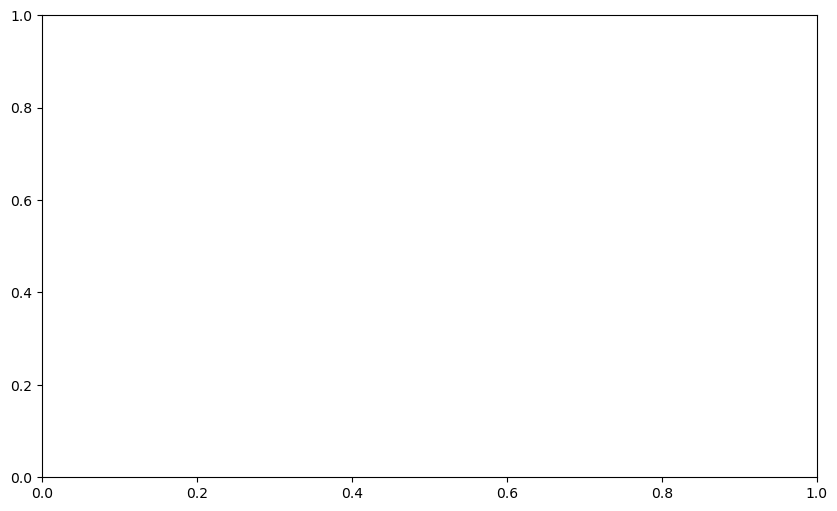

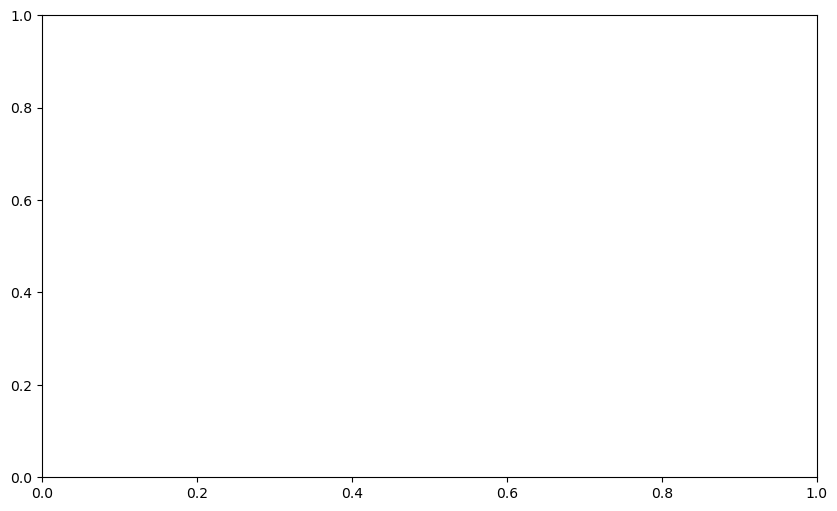

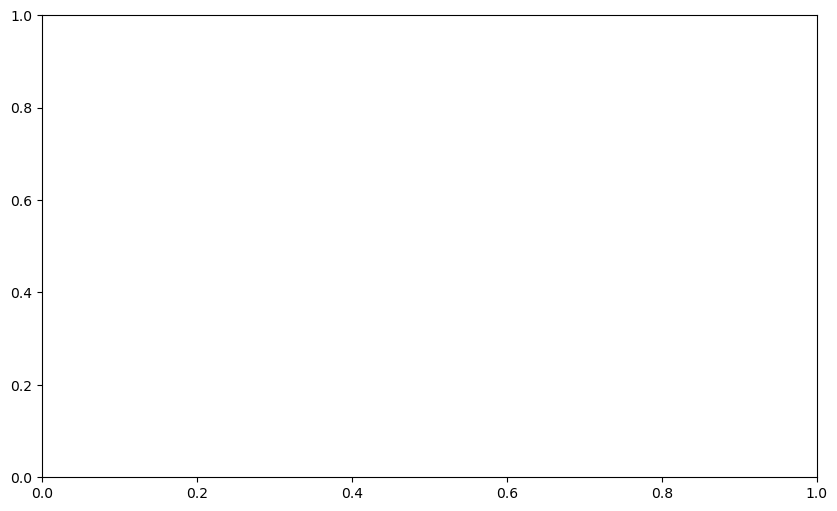

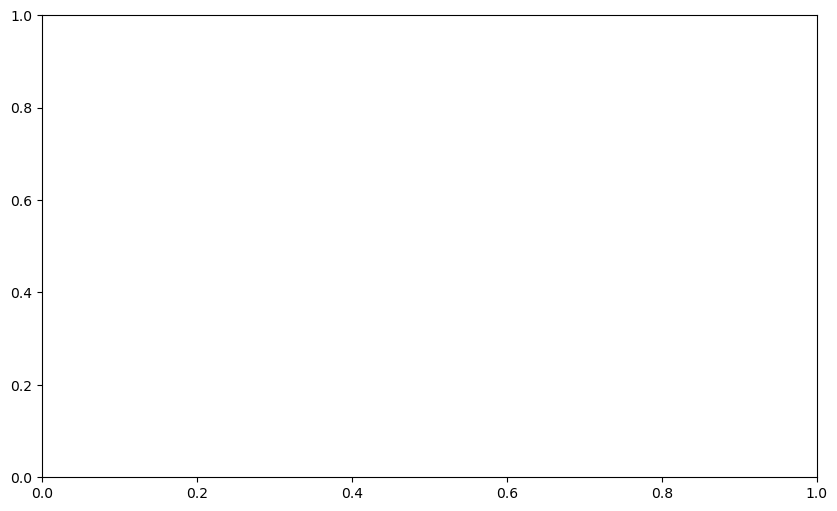

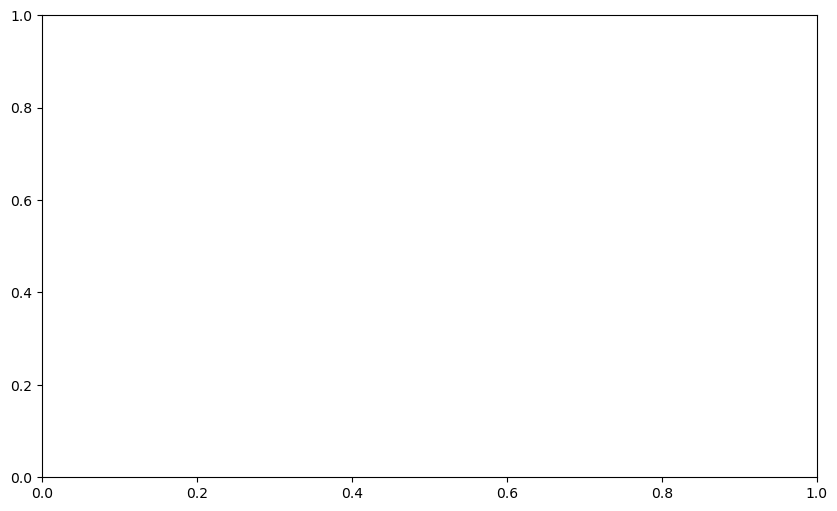

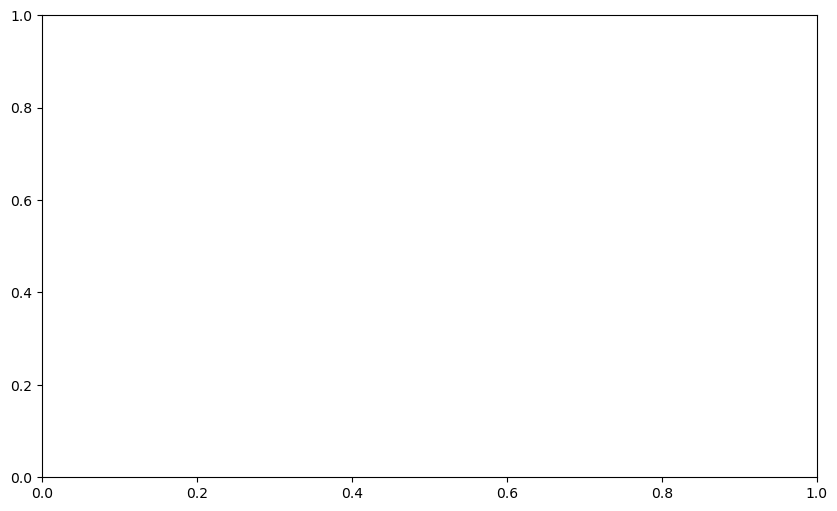

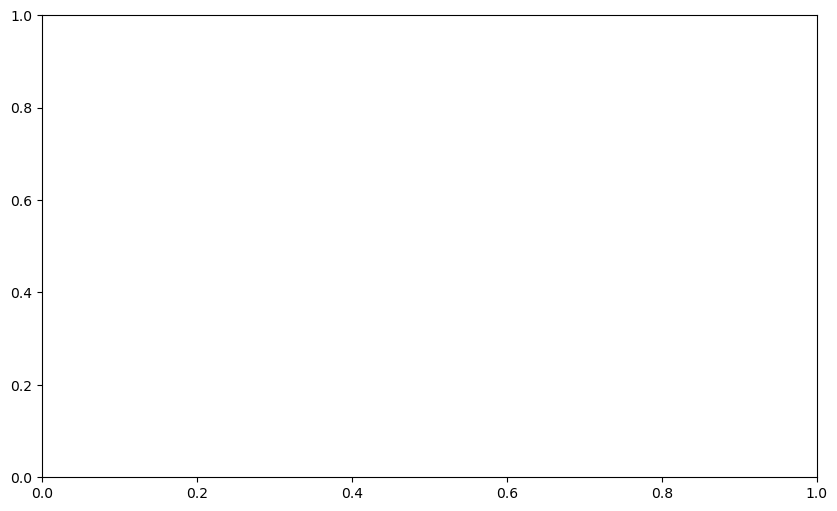

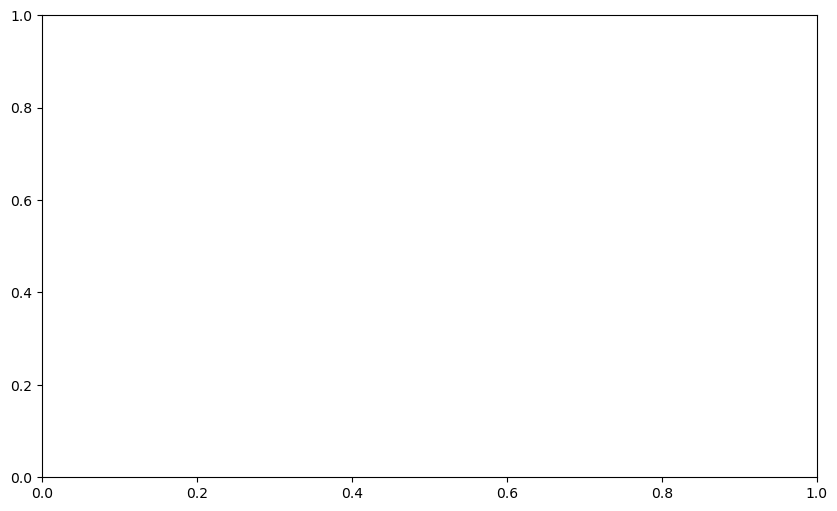

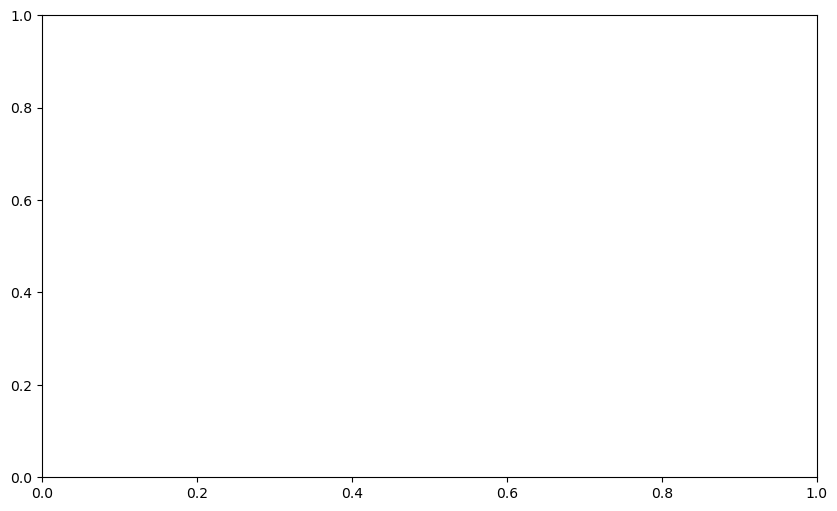

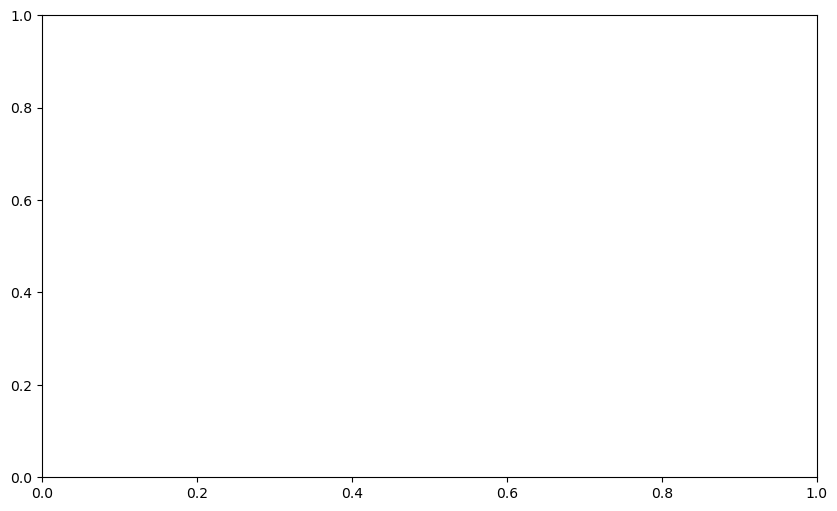

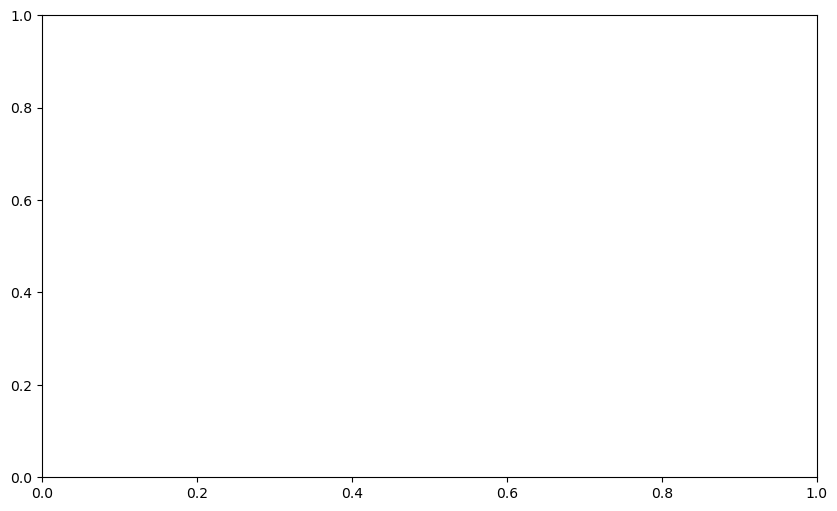

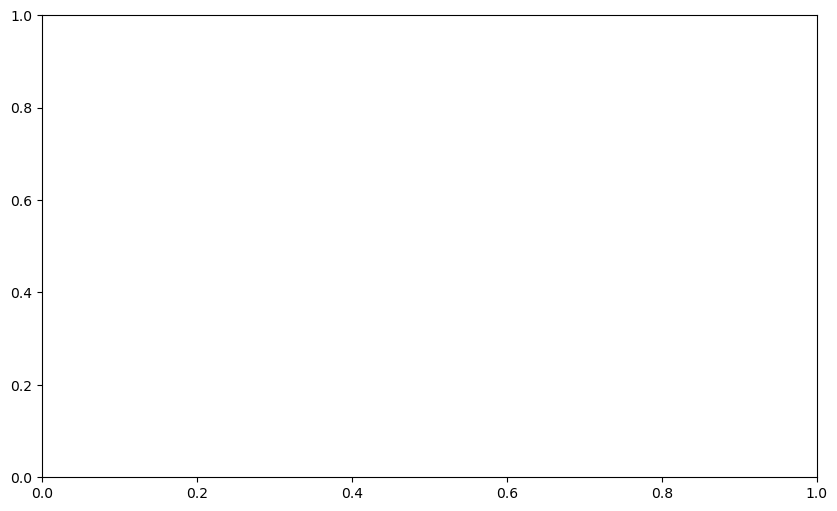

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatLogSlider, FloatSlider
import ipywidgets as widgets
from scipy import integrate


np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告

# 假设这些是您的模型和函数
# from your_model_library import B87Model, Planck_B_nu, Orion_opacity

def interactive_plot(n_0, gamma):
    # model = B87Model(n_0=n_0, gamma=gamma, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
    # model = OrionLRDModel(n_0=n_0, gamma=gamma, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
    model = OrionLRDModel(n_0=n_0, gamma=gamma, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
    try:
        plot_L_nu(model)
    except R_out_Error:
        print(f"Cannot find r_out")
    
    plt.title(f"{model:latex}")
    
    plt.legend()

interact(interactive_plot, 
         n_0=FloatLogSlider(value=1e3, base=10, min=0, max=6, step=0.1, description='n_0'), 
         gamma=FloatSlider(value=0, min=0, max=2, step=0.01, description='gamma'))

## Orion LRD model

In [ ]:
LRD_model = OrionLRDModel(n_0=1e3, gamma=0, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
LRD_model.UV_Flux(3), LRD_model.IR_Flux(np.array([1500]))

(6807696.661641899, 63165512.64480105)

In [ ]:
model_B87 = B87Model(n_0=1e3, gamma=0, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
model_Orion = OrionLRDModel(n_0=1e3, gamma=0, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
model_Orion.calc_L_nu(Orion_opacity, Orion_opacity.nu[::1])

array([2.98775022e-48, 3.02654129e-48, 3.07201783e-48, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [ ]:
plot_L_nu(model_Orion)
plot_L_nu(model_B87)

NameError: name 'plot_L_nu' is not defined

In [ ]:
np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告
%time LRD_model.UV_Flux(3)
%time LRD_model.IR_Flux(1500, method='quad')
%time LRD_model.IR_Flux(1500, method='quad_log')
%time LRD_model.IR_Flux(1500, method='trapz')
%time LRD_model.IR_Flux(1500, method='trapz_log')

CPU times: user 57 µs, sys: 328 µs, total: 385 µs
Wall time: 409 µs
CPU times: user 6.66 ms, sys: 2.36 ms, total: 9.01 ms
Wall time: 8.19 ms


KeyboardInterrupt: 

CPU times: user 878 µs, sys: 689 µs, total: 1.57 ms
Wall time: 2.31 ms
CPU times: user 724 µs, sys: 616 µs, total: 1.34 ms
Wall time: 1.38 ms


72011427.39709997

Text(0, 0.5, '$F_{\\rm UV} \\ [{\\rm erg/s/cm^2}]$')

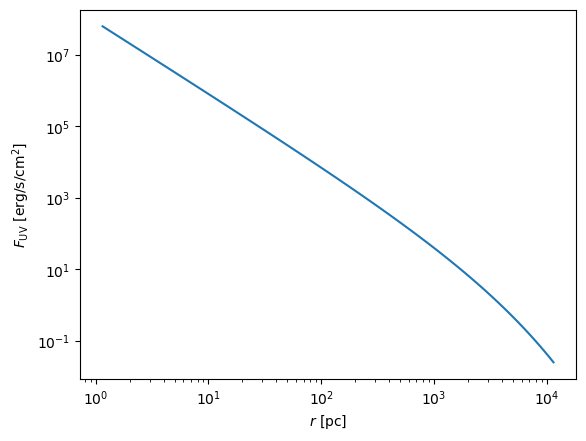

In [ ]:
LRD_model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
r_array = np.geomspace(LRD_model.r_in, 1e4*LRD_model.r_in, 100)
plt.loglog(r_array, LRD_model.UV_Flux(r_array))
plt.xlabel(r"$r$ [pc]")
plt.ylabel(r"$F_{\rm UV} \ [{\rm erg/s/cm^2}]$")

In [ ]:
%%time
r_array = np.geomspace(LRD_model.r_in, 1e2*LRD_model.r_in, 1000)
T_profile_array = [optimize.brentq(lambda T: LRD_model._T_dust_eqn(r, T), 1e-1, 3e3, xtol=1) for r in r_array]

CPU times: user 3.84 s, sys: 124 ms, total: 3.96 s
Wall time: 4.1 s


In [ ]:
plt.loglog(r_array, LRD_model.T_dust_profile_brentq(r_array), label='Orion')
plt.loglog(r_array, LRD_model.T_dust_profile(r_array), '--', label='Orion 2')
plt.loglog(r_array, model_B87.T_dust_profile(r_array) , label='B87')
plt.xlabel(r"$r$")
plt.ylabel(r"$T$")
# plt.yscale('linear')
plt.legend()

NameError: name 'LRD_model' is not defined

In [ ]:
LRD_model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
r_array = np.geomspace(LRD_model.r_in, LRD_model.r_out, 1000)
%time LRD_model.T_dust_profile_brentq(r_array)
%time LRD_model.T_dust_profile(r_array);

ValueError: f(a) and f(b) must have different signs

CPU times: user 194 ms, sys: 153 ms, total: 347 ms
Wall time: 371 ms


### compare with Li Zhengrong 2025 paper

In [4]:
model = OrionLRDModel(n_0=1e2, gamma=0., T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model.T_out

65.22712319924244

尝试 仿照 Figure 4，在 0.4 micron 的地方 normalize，但是因为我这里没加原始的 SED （消光后），所以 0.4 micron 的地方完全不对，结果也没法复现

/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/model_base.py:24: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)
/Users/chenkejian/Codes/JWST_LRD_SED/IR_spectrum/LRD_IR_spectrum/utils.py:52: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


13.97521604736074


/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_1810/568120985.py:8: RuntimeWarning: divide by zero encountered in divide
  ax.loglog(model.opacity.wavelength, L_nu / model.calc_L_nu(nu_array=([0.4] * u.micron).to(u.Hz), r_sample_num=1000))
/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_1810/568120985.py:8: RuntimeWarning: invalid value encountered in divide
  ax.loglog(model.opacity.wavelength, L_nu / model.calc_L_nu(nu_array=([0.4] * u.micron).to(u.Hz), r_sample_num=1000))


29.93632691118013
65.22712319924244
151.7959171891044


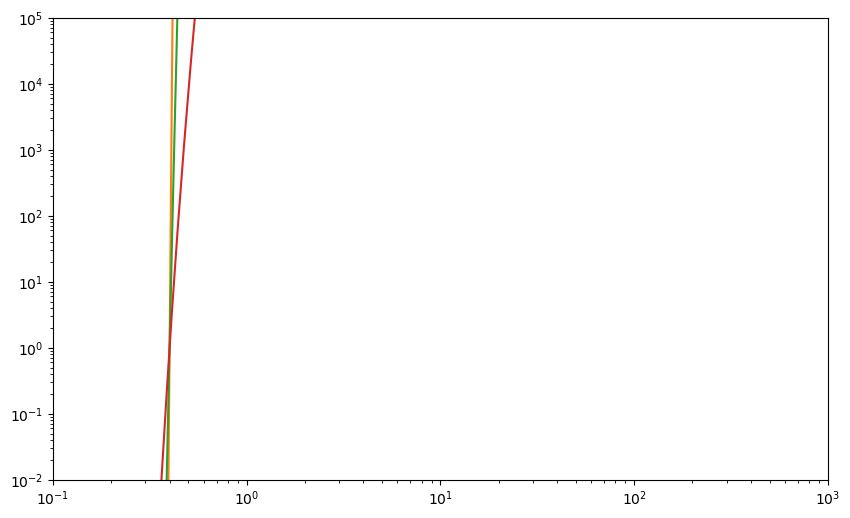

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(1e-1, 1e3)
ax.set_ylim(1e-2, 1e5)
for n_0 in np.geomspace(1e0, 1e3, 4):
    model = OrionLRDModel(n_0=n_0, gamma=0., T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
    L_nu = model.calc_L_nu(r_sample_num=1000)
    print(model.T_out)
    ax.loglog(model.opacity.wavelength, L_nu / model.calc_L_nu(nu_array=([0.4] * u.micron).to(u.Hz), r_sample_num=1000))

In [25]:
Temple_SED.L_nu

<Quantity [5.51047320e+29, 1.09699856e+30, 1.09711315e+30, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>

In [23]:
np.geomspace(1e0, 1e3, 4)

array([   1.,   10.,  100., 1000.])

In [9]:
np.geomspace(1e0, 1e3, 4)

array([   1.,   10.,  100., 1000.])

In [13]:
np.logspace(0,3, 4)

array([   1.,   10.,  100., 1000.])

In [15]:
10**np.arange(0, 4)

array([   1,   10,  100, 1000])